# Task 2.3 (Final Fixed Version)
Run all cells step by step

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)


## Load your data file

In [20]:
load_profiles = pd.read_csv('../data/load_profiles_step2.csv')
load_profiles.head()

,profile,minute,load_kW,set
0,1,1,492.6716,in_sample
1,1,2,471.3382,in_sample
2,1,3,459.0790,in_sample
3,1,4,462.6329,in_sample
4,1,5,461.3775,in_sample


## Compute availability

In [21]:
availability = (load_profiles.groupby(['profile','set'])['load_kW']
 .min()
 .reset_index()
 .rename(columns={'load_kW':'availability_kW'}))
availability.head()

,profile,set,availability_kW
0,1,in_sample,456.7977
1,2,in_sample,398.7703
2,3,in_sample,292.2239
3,4,in_sample,265.8739
4,5,in_sample,481.1360


## Split data

In [22]:
in_sample = availability[availability['set']=='in_sample']['availability_kW'].values
out_sample = availability[availability['set']=='out_of_sample']['availability_kW'].values


## Correct ALSO-X function

In [23]:
def alsox(avail, rel):
    avail_sorted = np.sort(avail)
    n = len(avail_sorted)

    if rel >= 0.999:
        return avail_sorted[0]

    k = int(np.floor((1 - rel) * n))
    k = min(max(k, 0), n - 1)

    return avail_sorted[k]


## Run Task 2.3

In [24]:
rows = []
for r in np.arange(0.80,1.01,0.01):
    bid = alsox(in_sample, r)
    shortfall = np.maximum(0, bid - out_sample)
    rows.append([r, bid, np.mean(shortfall)])

res = pd.DataFrame(rows, columns=['Reliability','Bid','Expected Shortfall'])
res


,Reliability,Bid,Expected Shortfall
0,0.80,314.4280,7.062677
1,0.81,311.5507,6.474344
2,0.82,310.0372,6.188672
3,0.83,303.7787,5.082633
4,0.84,303.4883,5.031812
5,0.85,298.8981,4.297827
6,0.86,295.3322,3.769541
7,0.87,292.2239,3.318838
8,0.88,284.5603,2.257773
9,0.89,282.3030,2.011448


## Plot results

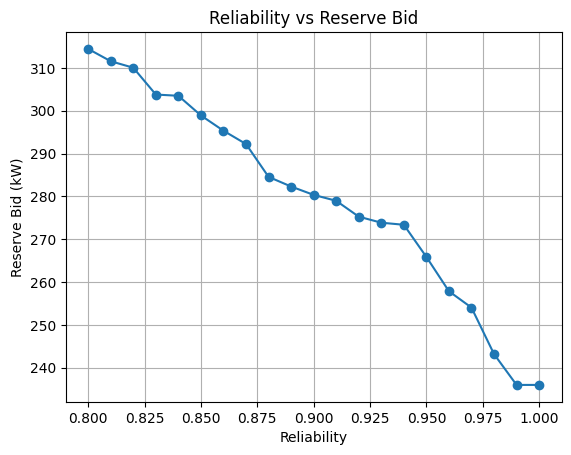

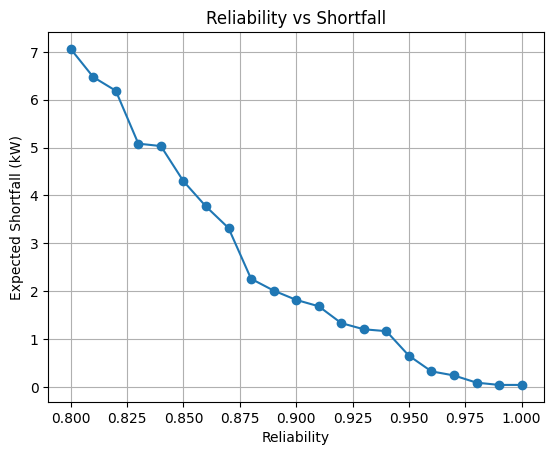

In [25]:
plt.figure()
plt.plot(res['Reliability'], res['Bid'], marker='o')
plt.xlabel('Reliability')
plt.ylabel('Reserve Bid (kW)')
plt.title('Reliability vs Reserve Bid')
plt.grid()
plt.show()

plt.figure()
plt.plot(res['Reliability'], res['Expected Shortfall'], marker='o')
plt.xlabel('Reliability')
plt.ylabel('Expected Shortfall (kW)')
plt.title('Reliability vs Shortfall')
plt.grid()
plt.show()


## Save results

In [26]:
res.to_csv('../results/task_2_3_results.csv', index=False)
print('Saved as task_2_3_results.csv')

Saved as task_2_3_results.csv
